In [1]:
import sys; sys.path.insert(0, "..")
import matplotlib.pyplot as plt
from src.data.align import align, gap_report, busiest_day

H5 = "../data/raw/ukdale.h5"

In [2]:
start, end = busiest_day(H5, 1, "kettle")
print(start.date())

2012-12-25


In [3]:
df = align(H5, 1, "kettle", start=start, end=end)
print(df.shape)
gap_report(df)

(14400, 2)


,missing_pct,longest_gap_min
mains,4.83,69.6
kettle,4.83,69.6


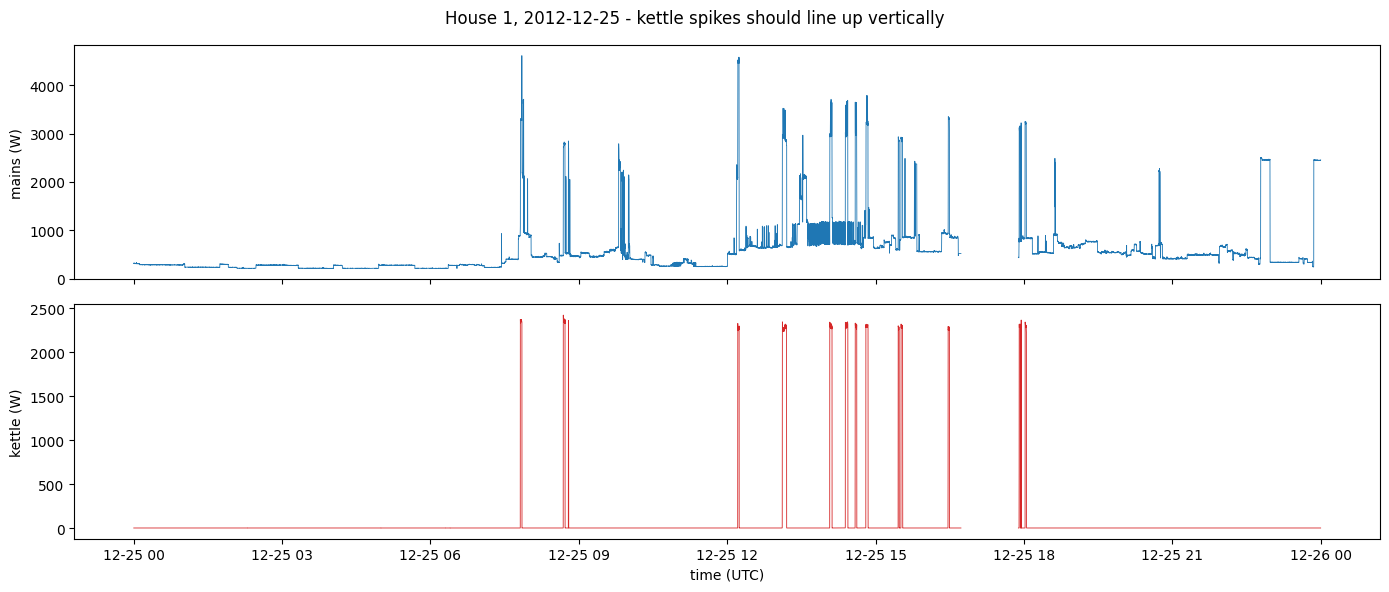

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax[0].plot(df.index, df["mains"], lw=0.6)
ax[0].set_ylabel("mains (W)")

ax[1].plot(df.index, df["kettle"], lw=0.6, color="tab:red")
ax[1].set_ylabel("kettle (W)")
ax[1].set_xlabel("time (UTC)")

fig.suptitle(f"House 1, {start.date()} - kettle spikes should line up vertically")
plt.tight_layout()

In [5]:
start5, end5 = busiest_day(H5, 5, "kettle")
print(start5.date())

2014-07-06


In [6]:
df5 = align(H5, 5, "kettle", start=start5, end=end5)
print(df5.shape)
gap_report(df5)

(14400, 2)


,missing_pct,longest_gap_min
mains,0.0,0.0
kettle,0.0,0.0


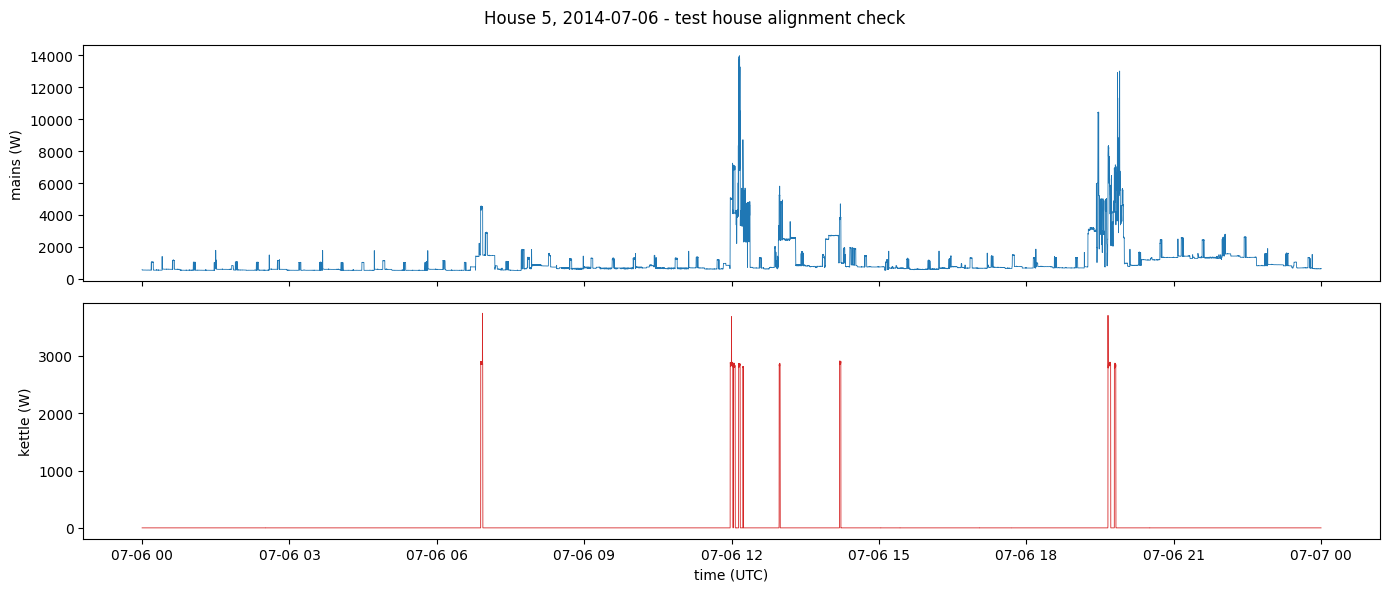

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax[0].plot(df5.index, df5["mains"], lw=0.6)
ax[0].set_ylabel("mains (W)")

ax[1].plot(df5.index, df5["kettle"], lw=0.6, color="tab:red")
ax[1].set_ylabel("kettle (W)")
ax[1].set_xlabel("time (UTC)")

fig.suptitle(f"House 5, {start5.date()} - test house alignment check")
plt.tight_layout()

In [8]:
df_month = align(H5, 1, "kettle", start="2013-06-01", end="2013-07-01")
gap_report(df_month)

,missing_pct,longest_gap_min
mains,0.00,0.0
kettle,0.04,7.2


In [9]:
for month in ["2013-06", "2014-06", "2015-06", "2016-06"]:
    d = align(H5, 1, "kettle", start=f"{month}-01", end=f"{month}-28")
    print(month, gap_report(d).to_dict()["missing_pct"])

2013-06 {'mains': 0.0, 'kettle': 0.04}
2014-06 {'mains': 0.0, 'kettle': 0.06}
2015-06 {'mains': 0.0, 'kettle': 0.39}
2016-06 {'mains': 0.0, 'kettle': 4.44}


In [10]:
for month in ["2016-12", "2017-03"]:
    d = align(H5, 1, "kettle", start=f"{month}-01", end=f"{month}-28")
    print(month, gap_report(d).to_dict()["missing_pct"])

2016-12 {'mains': 0.0, 'kettle': 2.01}
2017-03 {'mains': 0.0, 'kettle': 0.16}


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

base = pd.read_csv("../data/processed/baseline_kettle.csv",
                   index_col=0, parse_dates=True)
print(base.shape)
base.head()

(100800, 3)


,truth,CO,FHMM
2014-07-01 00:00:00+01:00,2.0,0.0,1.0
2014-07-01 00:00:06+01:00,2.0,0.0,1.0
2014-07-01 00:00:12+01:00,2.0,0.0,1.0
2014-07-01 00:00:18+01:00,2.0,0.0,1.0
2014-07-01 00:00:24+01:00,2.0,0.0,1.0


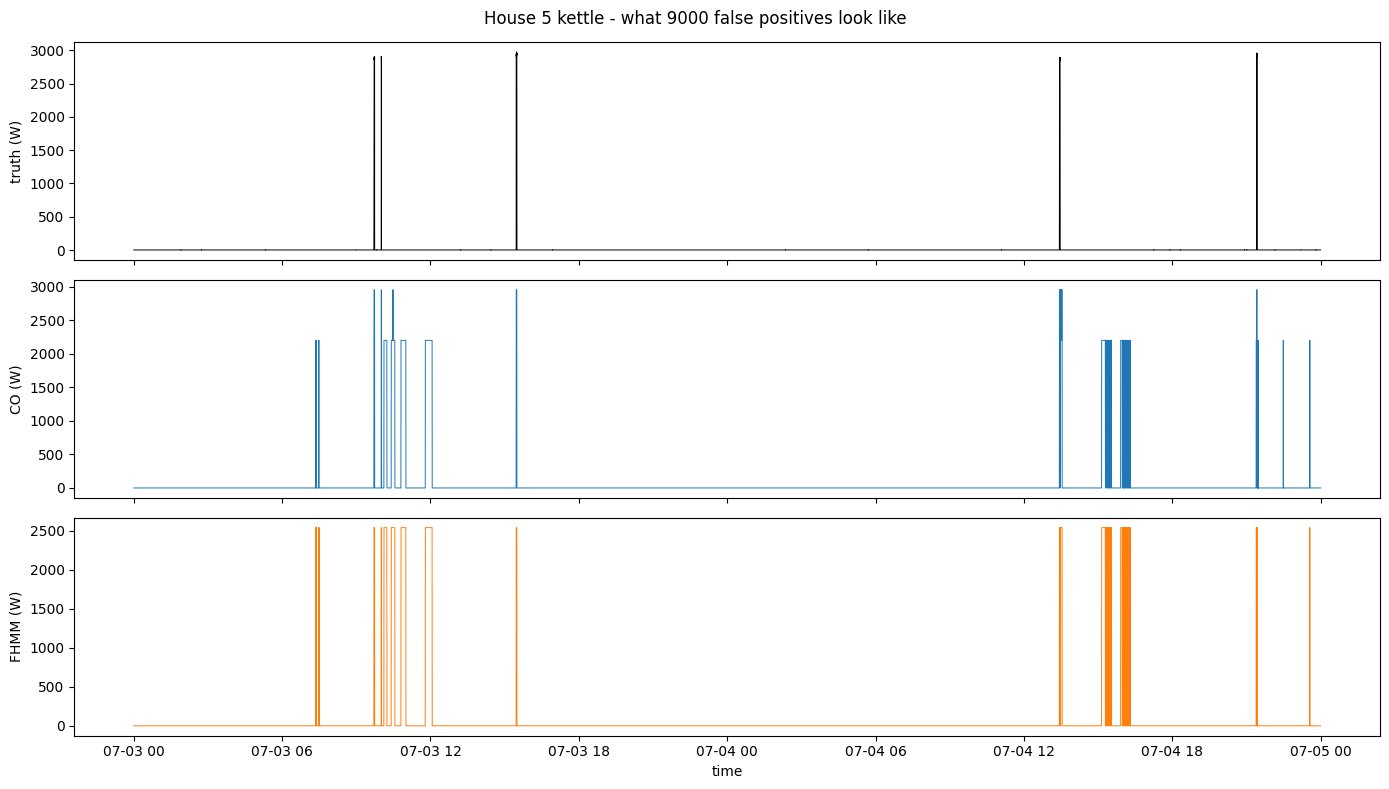

In [12]:
day = base.loc["2014-07-03":"2014-07-04"]

fig, ax = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

ax[0].plot(day.index, day["truth"], lw=0.7, color="black")
ax[0].set_ylabel("truth (W)")

ax[1].plot(day.index, day["CO"], lw=0.7, color="tab:blue")
ax[1].set_ylabel("CO (W)")

ax[2].plot(day.index, day["FHMM"], lw=0.7, color="tab:orange")
ax[2].set_ylabel("FHMM (W)")
ax[2].set_xlabel("time")

fig.suptitle("House 5 kettle - what 9000 false positives look like")
plt.tight_layout()

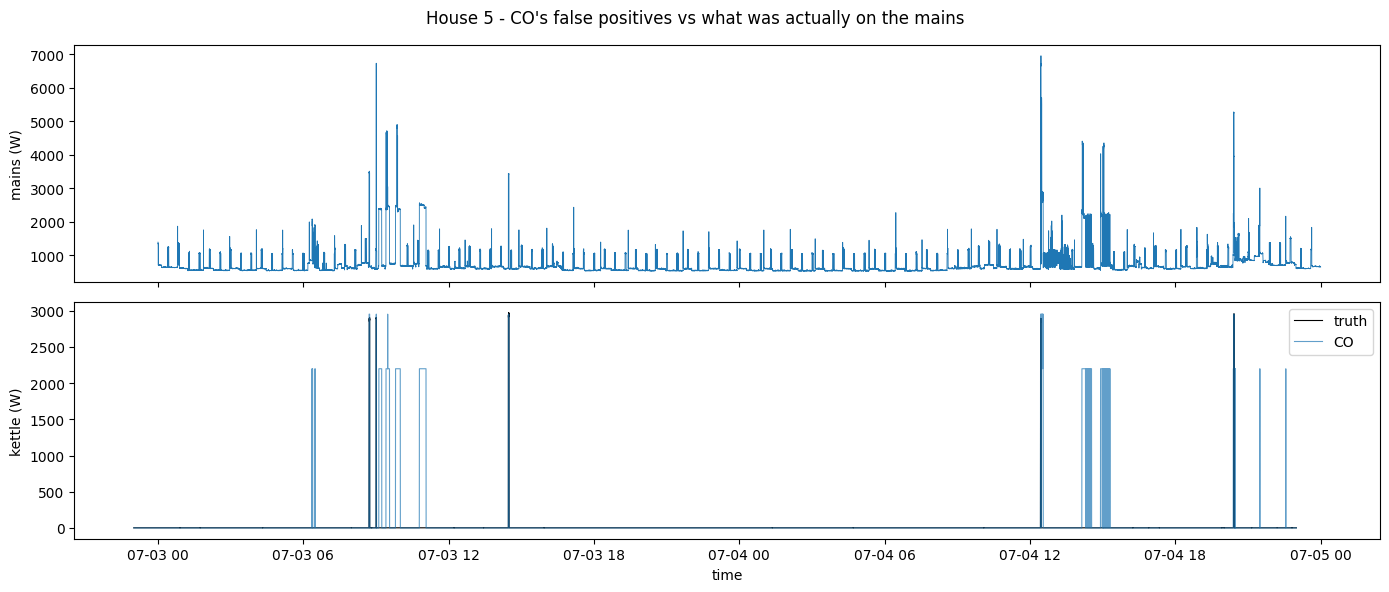

In [13]:
import sys; sys.path.insert(0, "..")
import pandas as pd
import matplotlib.pyplot as plt
from src.data.align import align

H5 = "../data/raw/ukdale.h5"

base = pd.read_csv("../data/processed/baseline_kettle.csv",
                   index_col=0, parse_dates=True)

# Both must cover the same span. Pandas string slicing includes the whole
# end day, so day runs 07-03 through 07-04 and align needs end=07-05.
day = base.loc["2014-07-03":"2014-07-04"]
agg = align(H5, 5, "kettle", start="2014-07-03", end="2014-07-05")

fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax[0].plot(agg.index, agg["mains"], lw=0.6)
ax[0].set_ylabel("mains (W)")

ax[1].plot(day.index, day["truth"], lw=0.8, color="black", label="truth")
ax[1].plot(day.index, day["CO"], lw=0.8, color="tab:blue", alpha=0.7, label="CO")
ax[1].legend()
ax[1].set_ylabel("kettle (W)")
ax[1].set_xlabel("time")

fig.suptitle("House 5 - CO's false positives vs what was actually on the mains")
plt.tight_layout()

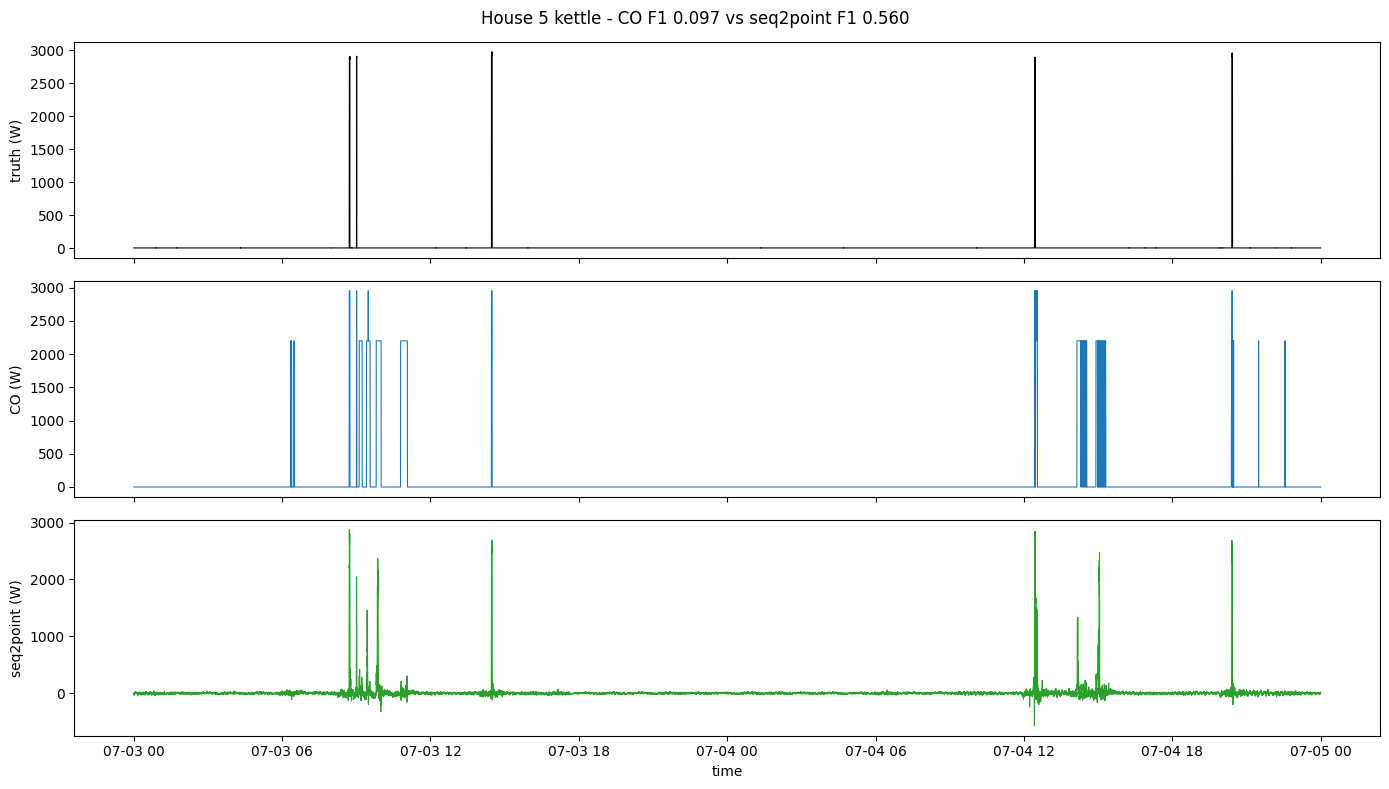

In [1]:
import sys; sys.path.insert(0, "..")
import pandas as pd
import matplotlib.pyplot as plt

s2p = pd.read_csv("../data/processed/seq2point_kettle_house5.csv",
                  index_col=0, parse_dates=True)
base = pd.read_csv("../data/processed/baseline_kettle.csv",
                   index_col=0, parse_dates=True)
base.index = base.index.tz_convert(s2p.index.tz)

lo, hi = "2014-07-03", "2014-07-04"
s = s2p.loc[lo:hi]
b = base.reindex(s.index)

fig, ax = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

ax[0].plot(s.index, s["truth"], lw=0.8, color="black")
ax[0].set_ylabel("truth (W)")

ax[1].plot(b.index, b["CO"], lw=0.8, color="tab:blue")
ax[1].set_ylabel("CO (W)")

ax[2].plot(s.index, s["seq2point"], lw=0.8, color="tab:green")
ax[2].set_ylabel("seq2point (W)")
ax[2].set_xlabel("time")

fig.suptitle("House 5 kettle - CO F1 0.097 vs seq2point F1 0.560")
plt.tight_layout()

In [2]:
import sys; sys.path.insert(0, "..")
import torch, pandas as pd
from src.data.align import align
from src.data.windows import WINDOW, Normaliser, make_windows
from src.models.seq2point import Seq2Point
from src.evaluate.cross_house import predict, sweep_threshold

ck = torch.load("../models/seq2point_kettle.pt", weights_only=False)
dev = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
m = Seq2Point(dilations=tuple(ck["dilations"])).to(dev)
m.load_state_dict(ck["state_dict"])
nrm = Normaliser.from_dict(ck["normaliser"])

# last two weeks of house 4 - training house, held-out period
df = align("../data/raw/ukdale.h5", 4, "kettle",
           start="2013-09-15", end="2013-10-01")
X, y = make_windows(df, "kettle", stride=1)
half = WINDOW // 2
idx = df.index[half:half + len(y)]
pred = pd.Series(predict(m, X, nrm, dev), index=idx)
truth = pd.Series(y, index=idx)

sw = sweep_threshold(pred, truth, "kettle")
print(sw.to_string(index=False))
print("\nbest:", sw.loc[sw.f1.idxmax()].to_dict())

 threshold  precision  recall    f1   tp   fp   fn
       250      0.335   0.982 0.500 1545 3066   29
       300      0.355   0.978 0.521 1539 2798   35
       350      0.375   0.973 0.541 1531 2555   43
       400      0.392   0.964 0.558 1517 2350   57
       450      0.411   0.956 0.574 1505 2161   69
       500      0.429   0.952 0.591 1498 1994   76
       550      0.447   0.946 0.607 1489 1845   85
       600      0.463   0.941 0.620 1481 1721   93
       650      0.480   0.939 0.635 1478 1603   96
       700      0.501   0.935 0.652 1471 1468  103
       750      0.522   0.931 0.669 1466 1344  108
       800      0.535   0.927 0.679 1459 1267  115
       850      0.552   0.921 0.690 1449 1178  125
       900      0.568   0.918 0.702 1445 1100  129
       950      0.584   0.910 0.711 1432 1022  142
      1000      0.605   0.903 0.724 1421  928  153
      1050      0.622   0.893 0.733 1406  856  168
      1100      0.640   0.887 0.743 1396  786  178
      1150      0.661   0.880 0

In [3]:
from src.evaluate.metrics import to_states, DEFAULT_THRESHOLDS

h5_pred = pd.read_csv("../data/processed/seq2point_kettle_house5.csv",
                      index_col=0, parse_dates=True)
cfg = DEFAULT_THRESHOLDS["kettle"]

tr = to_states(h5_pred["truth"], cfg["on_power"], cfg["min_on_s"], cfg["min_off_s"])
for t in (1000, 1550):
    p = to_states(h5_pred["seq2point"], t, cfg["min_on_s"], cfg["min_off_s"])
    tp = int((p & tr).sum()); fp = int((p & ~tr).sum()); fn = int((~p & tr).sum())
    prec = tp/(tp+fp) if tp+fp else 0
    rec = tp/(tp+fn) if tp+fn else 0
    f1 = 2*prec*rec/(prec+rec) if prec+rec else 0
    print(f"threshold {t}: precision {prec:.3f}  recall {rec:.3f}  F1 {f1:.3f}  "
          f"tp {tp}  fp {fp}  fn {fn}")

threshold 1000: precision 0.415  recall 0.861  F1 0.560  tp 428  fp 604  fn 69
threshold 1550: precision 0.555  recall 0.757  F1 0.640  tp 376  fp 302  fn 121
